# Fake News Prediction

## Team Members 

- Nathan Ford - X00229157
- Cody Juthan - X00221674
- Reece Lawlor Driver - X00220250

# Project Summary

### Import Required Libraries

We import essential Python libraries for working with data, visualisation, and machine learning model development. This supports repeatability and establishes our technical environment for the project.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



## Dataset Details and feature selection
Here we will be using feature selection on each individual dataset so that we may join them and use them as one big dataset.
We will then clean our data by ensuring there are no duplicates, null values etc

### First dataset 
Source: Kaggle Fake News Dataset (https://www.kaggle.com/code/anshahluwalia14/fake-news-detection/input)

Features: title, text, subject, date

License: Public dataset 

In [28]:
#Read in csv file as strings
#fake = pd.read_csv("REAL DATASETS/fakenewsdata/True.csv") 
#real = pd.read_csv("REAL DATASETS/fakenewsdata/Fake.csv")

#merged_files = pd.concat([fake, real], ignore_index=True)
#merged_files.head()
true = pd.read_csv("REAL DATASETS/True.csv")
fake = pd.read_csv("REAL DATASETS/Fake.csv")
true['label'] = 1  
fake['label'] = 0   
first_data = pd.concat([true, fake], ignore_index=True)
first_data.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


### Second dataset:
Fake news dataset source: https://www.kaggle.com/datasets/amar5693/fake-and-real-news-dataset-4k


In [29]:
second_data = pd.read_csv("REAL DATASETS/fake_news_dataset_4000_rows.csv")
second_data.head()

,id,title,text,author,source,topic,publish_date,year,month,day,word_count,char_count,title_length,label
0,1,Miracle Cure Update 1,This article discusses Miracle Cure Update 1. ...,Guest Writer,ViralNow,Miracle Cure,2023-09-30,2023,9,30,32,219,21,0
1,2,Conspiracy Update 2,This article discusses Conspiracy Update 2. Ho...,Unknown Reporter,RumorTimes,Conspiracy,2024-07-29,2024,7,29,31,217,19,0
2,3,Technology Update 3,This article discusses Technology Update 3. Th...,Ayesha Khan,BBC News,Technology,2023-05-19,2023,5,19,29,210,19,1
3,4,Economy Update 4,This article discusses Economy Update 4. The i...,Fatima Noor,Al Jazeera,Economy,2023-09-09,2023,9,9,29,207,16,1
4,5,Conspiracy Update 5,This article discusses Conspiracy Update 5. Ho...,Anonymous,RumorTimes,Conspiracy,2024-09-03,2024,9,3,31,217,19,0


As we can see the second dataset is very different to the first. If we are to train all this data together me must make them similar. 
To do this we will drop all but four columns and rename them so they may work alongside our other datasets

In [30]:
#Choosing the columns we will be working with
second_data = second_data[["title", "text", "topic", "publish_date","label"]]

#Renaming feature columns so they align with our other datasets
second_data = second_data.rename(columns={"topic" : "subject",
                                          "publish_date" : "date"})

second_data.head()

,title,text,subject,date,label
0,Miracle Cure Update 1,This article discusses Miracle Cure Update 1. ...,Miracle Cure,2023-09-30,0
1,Conspiracy Update 2,This article discusses Conspiracy Update 2. Ho...,Conspiracy,2024-07-29,0
2,Technology Update 3,This article discusses Technology Update 3. Th...,Technology,2023-05-19,1
3,Economy Update 4,This article discusses Economy Update 4. The i...,Economy,2023-09-09,1
4,Conspiracy Update 5,This article discusses Conspiracy Update 5. Ho...,Conspiracy,2024-09-03,0


### Third dataset
Dataset source: 

In [31]:
third_data = pd.read_csv("REAL DATASETS/fake_news_dataset1.csv",)
third_data['label'] = third_data['label'].map({
    'real': 1,
    'fake': 0})
third_data.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,1
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,0
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,0
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,0
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,0


In [32]:
#Choosing the columns we would like to work with
third_data = third_data[["title", "text", "date", "category","label"]]

#Renaming category to subject
third_data = third_data.rename(columns={"category" : "subject"})

third_data.head()

,title,text,date,subject,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,Politics,1
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Politics,0
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,Business,0
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Science,0
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,Technology,0


As we can see all the datasets now have matching feature columns, this means we can join them to make one big dataset.

In [33]:
#This will use pandas to join all the datasets and ignore headers
data = pd.concat([first_data, second_data, third_data], ignore_index=True)
data.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


## Data cleaning and wrangling

Following best-practice guidelines, we check for:
- Missing values
- Duplicate records
- Incorrect or extreme values
- Data types


In [34]:
# Missing values summary
data.isna().sum()


title      0
text       0
subject    0
date       0
label      0
dtype: int64

There's zero missing values in all columns

### Checked to see if there is any duplicate data

In [35]:
#Detect any duplicate rows and drop them
duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

print("Data shape before dropping duplicates:", data.shape)


if duplicates > 0:
    data = data.drop_duplicates()

print(f"\nData shape after dropping duplicates:", data.shape)


Duplicate rows: 209
Data shape before dropping duplicates: (68898, 5)

Data shape after dropping duplicates: (68689, 5)


There were 209 duplicated rows so we dropped them.

In [36]:
data.describe()


,label
count,68689.000000
mean,0.482552
std,0.499699
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


## Pre Processing

In [37]:

# Check original shape
print("Data shape before processing:", data.shape)

# Define features (X) and target (y)
X = data[["title", "text", "date","label"]]   # input features
y = data["subject"]                  # target label

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Data shape before processing: (68689, 5)
Feature shape: (68689, 4)
Target shape: (68689,)


# Graphing the data

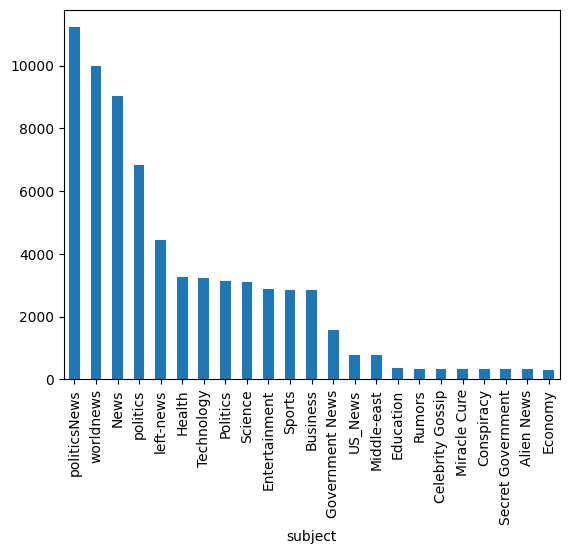

In [38]:
data["subject"].value_counts().plot(kind="bar")

plt.show()

This graph highlights the number of articles relating to each news subject

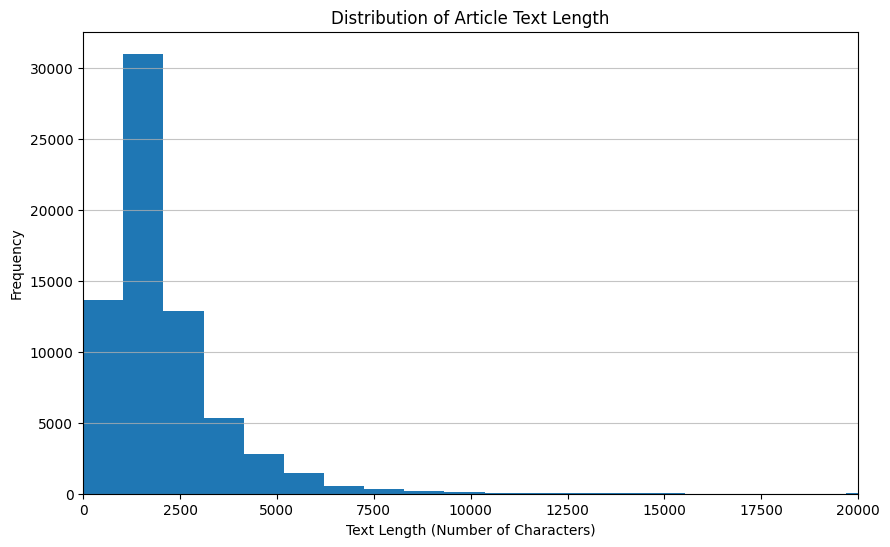

In [39]:
plt.figure(figsize=(10,6))
data["text_length"] = data["text"].apply(len)
plt.hist(data["text_length"], bins=50)

plt.xlabel("Text Length (Number of Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Article Text Length")

plt.xlim(0, 20000)  

plt.grid(axis="y", alpha=0.75)
plt.show()



This graph displays the text length of the articles 

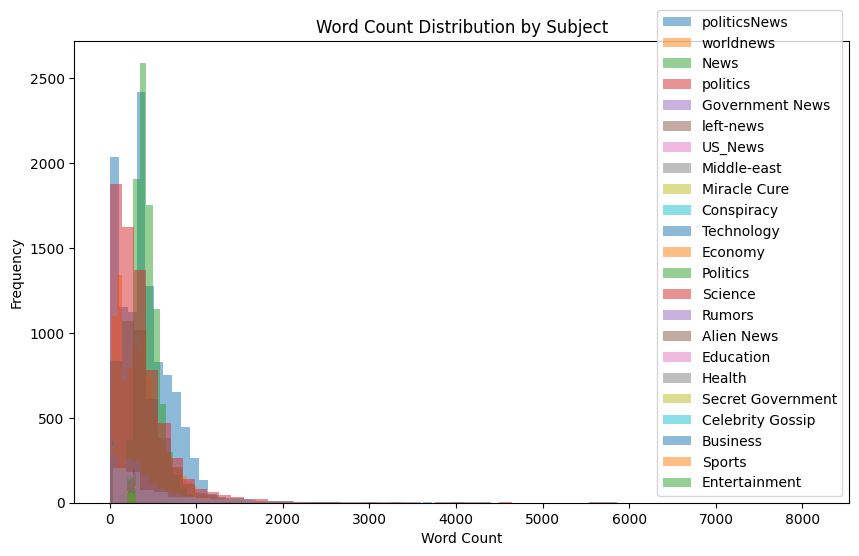

In [40]:
data["word_count"] = data["text"].str.split().str.len()

plt.figure(figsize=(10,6))

for label in data["subject"].unique():
    subset = data[data["subject"] == label]
    plt.hist(subset["word_count"], bins=50, alpha=0.5, label=label)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution by Subject")
plt.legend()
plt.show()

This graph showcases the frequency of each subject in our dataset

### Splitting the data for training

Hold out validation - Dataset is split into training and test sets. The model is trained on the training data and evaluated once on unseen test data to measure performance.

In [41]:
# Prepare Data
data["content"] = data["title"] + " " + data["text"] + " " + data["subject"]
X = data["content"]
y = data["label"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

#Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Train size: (54951,)
Test size: (13738,)


## Models
Definitions:
- Precision - measures how many of the items the model predicted as positive were actually positive. It reflects how well the model avoids false positives.
- Recall - measures how many of the actual positive items the model successfully identified. It reflects how well the model avoids false negatives.
- The F1‑score is the harmonic mean of precision and recall. It provides a single balanced metric that considers both false positives and false negatives, useful when class accuracy needs to be compared fairly.
- Macro Averaging - calculates precision, recall, and F1‑score for each class individually, then averages them equally. Each class is given the same weight, regardless of class size. This shows how well the model performs per class.
- Weighted Averaging - calculates each metric per class, but weights each class by the number of samples it contains.
This gives a more realistic overall performance when classes are imbalanced.


## Logistic Regression

In [ ]:
#Model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

#Prediction
y_pred = model.predict(X_test_vec)

#Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8456107148056485

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      7109
           1       0.84      0.84      0.84      6629

    accuracy                           0.85     13738
   macro avg       0.85      0.85      0.85     13738
weighted avg       0.85      0.85      0.85     13738



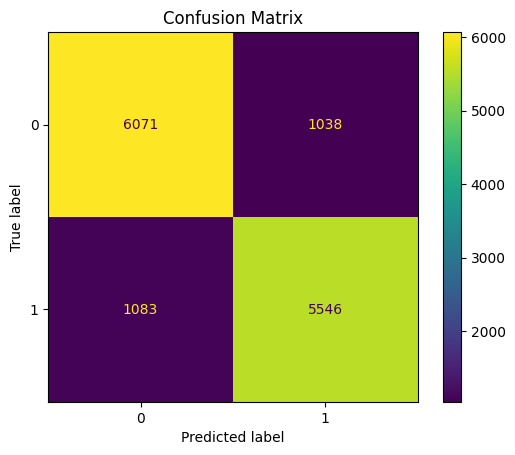

In [43]:
#Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

The Logistic Regression model correctly identified 6071 true negatives and 5546 true positives.
This means it correctly classified 6071 fake articles and 5546 real articles.

There were 1038 false positives, where real articles were incorrectly predicted as fake, and 1083 false negatives, where fake articles were incorrectly predicted as real.

### Support Vector Machine

In [44]:
# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

y_pred_svm = svm_model.predict(X_test_vec)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8521618867375164

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      7109
           1       0.85      0.85      0.85      6629

    accuracy                           0.85     13738
   macro avg       0.85      0.85      0.85     13738
weighted avg       0.85      0.85      0.85     13738



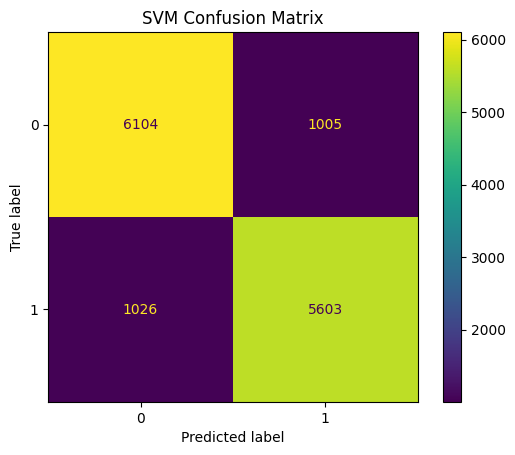

In [45]:
## Matrix for SVM model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()


The SVM model correctly identified 6104 true negatives and 5603 true positives. This means it correctly classified 6104 fake articles and 5603 real articles.

There were 1005 false positives, where real articles were incorrectly predicted as fake, and 1026 false negatives, where fake articles were incorrectly predicted as real.

### Naive Bayes

In [46]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.817586257097103

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.76      0.81      7109
           1       0.77      0.88      0.82      6629

    accuracy                           0.82     13738
   macro avg       0.82      0.82      0.82     13738
weighted avg       0.82      0.82      0.82     13738



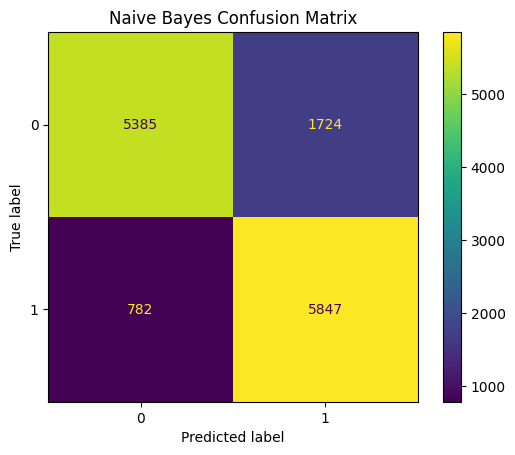

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

The Naive Bayes model correctly identified 5385 true negatives and 5847 true positives. This means it correctly classified 5385 fake articles and 5847 real articles.

There were 1724 false positives, where real articles were incorrectly predicted as fake, and 782 false negatives, where fake articles were incorrectly predicted as real.

### Models Summary
- Logistic Regression comes in at 85.3% accurate.
- Support Vector Machine comes in at 86% accurate
- Naive Bayes comes in at 81.38% accurate.

With these results after analysing our individual models the best fit model we found is Support Vector Machine and this is what we will use moving forward.